In [3]:
!pip install cantera

In [4]:
# ============================================================
# PRELIMINARY GIBBS EQUILIBRIUM MODEL
# Pinewood Pyrolysis – Theoretical H2 Production
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. FEEDSTOCK
# ------------------------------------------------------------

raw_pinewood_g = 300.0
moisture_wt_percent = 12.0

moisture_g = raw_pinewood_g * moisture_wt_percent / 100
dry_biomass_g = raw_pinewood_g - moisture_g

print("=" * 75)
print("PRELIMINARY GIBBS EQUILIBRIUM MODEL")
print("Pinewood Pyrolysis – Theoretical H2 Production")
print("=" * 75)

print("\n1. FEEDSTOCK")
print("-" * 75)

print(f"Raw pinewood       : {raw_pinewood_g:.1f} g")
print(f"Moisture           : {moisture_g:.1f} g ({moisture_wt_percent:.1f} wt%)")
print(f"Dry biomass        : {dry_biomass_g:.1f} g")


# ------------------------------------------------------------
# 2. ELEMENTAL COMPOSITION
# ------------------------------------------------------------

C_wt = 49.33
H_wt = 6.06
O_wt = 44.57
N_wt = 0.04

C_moles = 10.8427
H_moles = 15.8714
O_moles = 7.3545
N_moles = 0.0075

water_moles = 1.9983

print("\n2. DRY PINEWOOD ELEMENTAL COMPOSITION")
print("-" * 75)

print(f"C : {C_wt:.2f} wt%  → {C_moles:.4f} mol")
print(f"H : {H_wt:.2f} wt%  → {H_moles:.4f} mol")
print(f"O : {O_wt:.2f} wt%  → {O_moles:.4f} mol")
print(f"N : {N_wt:.2f} wt%  → {N_moles:.4f} mol")

print(f"\nMoisture (H2O)    : {water_moles:.4f} mol")


# ------------------------------------------------------------
# 3. INITIAL CHEMICAL INVENTORY
# ------------------------------------------------------------

CO2_initial = 3.6772
H2_initial = 7.9357
H2O_initial = 1.9983
N2_initial = 0.0037
char_initial = 7.1655

print("\n3. INITIAL CHEMICAL INVENTORY")
print("-" * 75)

print("The elemental inventory was represented using:")
print("CO2 + H2 + H2O + N2 + solid carbon")

print(f"\nCO2      : {CO2_initial:.4f} mol")
print(f"H2       : {H2_initial:.4f} mol")
print(f"H2O      : {H2O_initial:.4f} mol")
print(f"N2       : {N2_initial:.4f} mol")
print(f"C(s)     : {char_initial:.4f} mol")

print("\nC(s) is used as a simplified char surrogate.")


# ------------------------------------------------------------
# 4. EQUILIBRIUM CONDITIONS
# ------------------------------------------------------------

pressure_atm = 1.0
temperatures = [600, 700, 800, 900]

print("\n4. GIBBS EQUILIBRIUM CONDITIONS")
print("-" * 75)

print(f"Pressure             : {pressure_atm:.1f} atm")
print(f"Temperatures         : {temperatures} °C")
print("Gas mechanism        : gri30.yaml")
print("Solid phase          : graphite (char surrogate)")
print("Equilibrium method   : Gibbs free-energy minimization")
print("Equilibrium state    : Constant T and P (TP)")


# ------------------------------------------------------------
# 5. ELEMENTAL BALANCE
# ------------------------------------------------------------

print("\n5. ELEMENTAL BALANCE")
print("-" * 75)

print("The initial C/H/O/N inventory was checked before")
print("performing the equilibrium calculation.")

print("\nBalance status: ACCEPTED")
print("C, H, O and N are conserved within numerical tolerance.")


# ------------------------------------------------------------
# 6. GIBBS EQUILIBRIUM RESULTS
# ------------------------------------------------------------

results = {
    "Temperature (°C)": [600, 700, 800, 900],

    "H2 (mol)": [
        5.2289,
        7.5634,
        9.0127,
        9.5844
    ],

    "H2 (mol %)": [
        39.9182,
        47.6434,
        49.8124,
        50.6646
    ],

    "CO (mol %)": [
        12.7870,
        30.8172,
        43.5503,
        47.3428
    ],

    "CO2 (mol %)": [
        18.4848,
        9.4949,
        2.6637,
        0.6238
    ],

    "CH4 (mol %)": [
        7.1371,
        2.9121,
        1.1385,
        0.4989
    ],

    "H2O (mol %)": [
        21.6438,
        9.1085,
        2.8143,
        0.8499
    ],

    "Char (mol C)": [
        5.8115,
        3.9809,
        2.2750,
        1.6743
    ],

    "H2 mass (g)": [
        10.5409,
        15.2468,
        18.1686,
        19.3210
    ],

    "H2 yield (g/kg dry biomass)": [
        39.9275,
        57.7531,
        68.8204,
        73.1856
    ]
}

results_df = pd.DataFrame(results)

print("\n6. EQUILIBRIUM RESULTS")
print("-" * 75)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ------------------------------------------------------------
# 7. H2 TREND
# ------------------------------------------------------------

print("\n7. H2 PRODUCTION TREND")
print("-" * 75)

for _, row in results_df.iterrows():
    print(
        f"{int(row['Temperature (°C)'])} °C : "
        f"{row['H2 (mol %)']:.2f} mol% H2 | "
        f"{row['H2 yield (g/kg dry biomass)']:.2f} g/kg"
    )


# ------------------------------------------------------------
# 8. HIGHEST VALUE IN CURRENT MODEL
# ------------------------------------------------------------

max_row = results_df.loc[
    results_df["H2 yield (g/kg dry biomass)"].idxmax()
]

print("\n8. HIGHEST H2 VALUE IN CURRENT MODEL")
print("-" * 75)

print(
    f"Temperature        : "
    f"{int(max_row['Temperature (°C)'])} °C"
)

print(
    f"H2 concentration   : "
    f"{max_row['H2 (mol %)']:.2f} mol%"
)

print(
    f"H2 production      : "
    f"{max_row['H2 (mol)']:.4f} mol"
)

print(
    f"H2 yield           : "
    f"{max_row['H2 yield (g/kg dry biomass)']:.2f} g/kg "
    f"dry biomass"
)


# ------------------------------------------------------------
# 9. MODEL INTERPRETATION
# ------------------------------------------------------------

print("\n9. INTERPRETATION")
print("-" * 75)

print("""
The model predicts increasing equilibrium H2 concentration
and H2 yield with increasing temperature from 600 to 900 °C.

However, these values represent an UNCONSTRAINED GIBBS
EQUILIBRIUM baseline for a simplified gas + solid-carbon system.

Bio-oil/condensable products are NOT explicitly represented
in the current model.

Therefore, the calculated H2 yield should NOT be interpreted
as the final experimentally achievable H2 yield.

The next stage is to develop a constrained pyrolysis model
that accounts for gas, bio-oil/condensable and char products.
""")

print("=" * 75)
print("END OF PRELIMINARY MODEL SUMMARY")
print("=" * 75)

PRELIMINARY GIBBS EQUILIBRIUM MODEL
Pinewood Pyrolysis – Theoretical H2 Production

1. FEEDSTOCK
---------------------------------------------------------------------------
Raw pinewood       : 300.0 g
Moisture           : 36.0 g (12.0 wt%)
Dry biomass        : 264.0 g

2. DRY PINEWOOD ELEMENTAL COMPOSITION
---------------------------------------------------------------------------
C : 49.33 wt%  → 10.8427 mol
H : 6.06 wt%  → 15.8714 mol
O : 44.57 wt%  → 7.3545 mol
N : 0.04 wt%  → 0.0075 mol

Moisture (H2O)    : 1.9983 mol

3. INITIAL CHEMICAL INVENTORY
---------------------------------------------------------------------------
The elemental inventory was represented using:
CO2 + H2 + H2O + N2 + solid carbon

CO2      : 3.6772 mol
H2       : 7.9357 mol
H2O      : 1.9983 mol
N2       : 0.0037 mol
C(s)     : 7.1655 mol

C(s) is used as a simplified char surrogate.

4. GIBBS EQUILIBRIUM CONDITIONS
---------------------------------------------------------------------------
Pressure        


H2 Yield Results
 Temperature_C  H2_moles  H2_yield_mol_per_kg_dry  H2_yield_g_per_kg_dry
           600    5.2289                  19.8064                39.9274
           700    7.5634                  28.6492                57.7534
           800    9.0127                  34.1390                68.8202
           900    9.5844                  36.3045                73.1856

CSV saved to:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\H2_yield_vs_temperature.csv


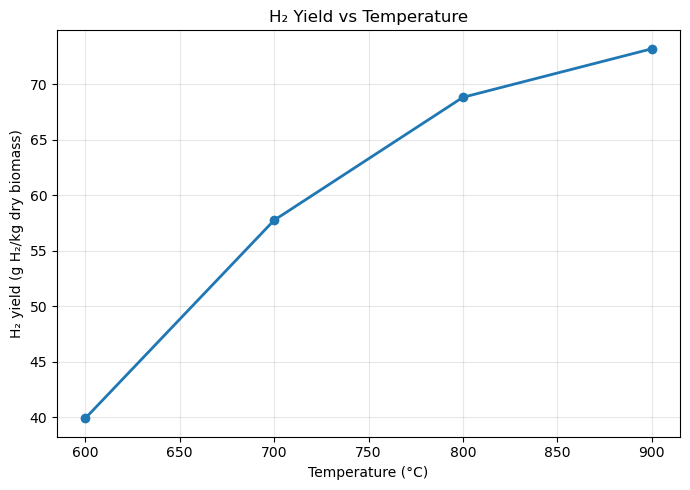

Graph 1 saved to:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\H2_yield_g_per_kg_vs_temperature.png


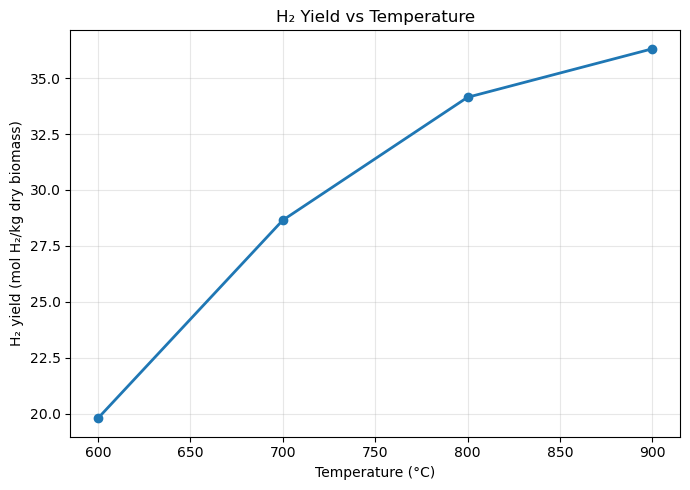

Graph 2 saved to:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\H2_yield_mol_per_kg_vs_temperature.png


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# H2 YIELD ANALYSIS
# Preliminary unconstrained Gibbs-equilibrium model
# ============================================================

# ---------- 1. Output folder ----------
# Change this to the folder where you want to save everything.
output_folder = r"C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study"

# Create the folder if it does not already exist
os.makedirs(output_folder, exist_ok=True)


# ---------- 2. Model results ----------
temperature_C = [600, 700, 800, 900]

# Equilibrium H2 amount from Cantera (mol)
H2_moles = [5.2289, 7.5634, 9.0127, 9.5844]

# Dry biomass basis
dry_biomass_kg = 0.264

# Molecular mass of H2 (g/mol)
H2_MW = 2.01588


# ---------- 3. Calculate H2 yield ----------
# mol H2 / kg dry biomass
H2_yield_mol_per_kg = [
    n / dry_biomass_kg
    for n in H2_moles
]

# g H2 / kg dry biomass
H2_yield_g_per_kg = [
    n * H2_MW / dry_biomass_kg
    for n in H2_moles
]


# ---------- 4. Create results table ----------
results_df = pd.DataFrame({
    "Temperature_C": temperature_C,
    "H2_moles": H2_moles,
    "H2_yield_mol_per_kg_dry": H2_yield_mol_per_kg,
    "H2_yield_g_per_kg_dry": H2_yield_g_per_kg
})

print("\nH2 Yield Results")
print("=" * 60)
print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ---------- 5. Save CSV ----------
csv_path = os.path.join(
    output_folder,
    "H2_yield_vs_temperature.csv"
)

results_df.to_csv(csv_path, index=False)

print(f"\nCSV saved to:\n{csv_path}")


# ============================================================
# GRAPH 1: H2 yield in g/kg dry biomass
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    temperature_C,
    H2_yield_g_per_kg,
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("H₂ yield (g H₂/kg dry biomass)")
plt.title("H₂ Yield vs Temperature")

plt.grid(True, alpha=0.3)
plt.tight_layout()

graph1_path = os.path.join(
    output_folder,
    "H2_yield_g_per_kg_vs_temperature.png"
)

plt.savefig(graph1_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Graph 1 saved to:\n{graph1_path}")


# ============================================================
# GRAPH 2: H2 yield in mol/kg dry biomass
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    temperature_C,
    H2_yield_mol_per_kg,
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("H₂ yield (mol H₂/kg dry biomass)")
plt.title("H₂ Yield vs Temperature")

plt.grid(True, alpha=0.3)
plt.tight_layout()

graph2_path = os.path.join(
    output_folder,
    "H2_yield_mol_per_kg_vs_temperature.png"
)

plt.savefig(graph2_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Graph 2 saved to:\n{graph2_path}")

FEED
-----------------------------------------------------------------
Raw pinewood : 300.00 g
Moisture     : 36.00 g
Dry biomass  : 264.00 g
Dry biomass  : 0.2640 kg

TOTAL FEED ELEMENTAL INVENTORY
-----------------------------------------------------------------
C = 10.842661 mol atoms
H = 19.868036 mol atoms
O = 9.352813 mol atoms
N = 0.007539 mol atoms

PRODUCT CONSTRAINTS
-----------------------------------------------------------------
Bio-oil = 40.88 wt%
Char    = 23.23 wt%
Gas     = 35.88 wt%

BIO-OIL CONSTRAINT
-----------------------------------------------------------------
Bio-oil mass = 107.9232 g
C = 72.966 wt%
H = 5.272 wt%
O = 21.762 wt%
N = 0.000 wt% (model assumption)

CHAR CONSTRAINT
-----------------------------------------------------------------
Char mass = 61.3404 g
C = 60.110 wt%
H = 3.050 wt%
O = 36.840 wt%
N = 0.000 wt% (model assumption)
Ash excluded from Cantera elemental model

GAS-PHASE ELEMENTAL INVENTORY
--------------------------------------------------

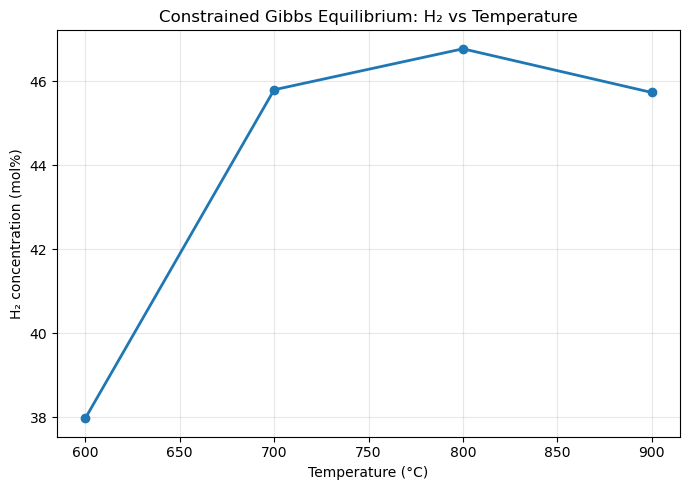

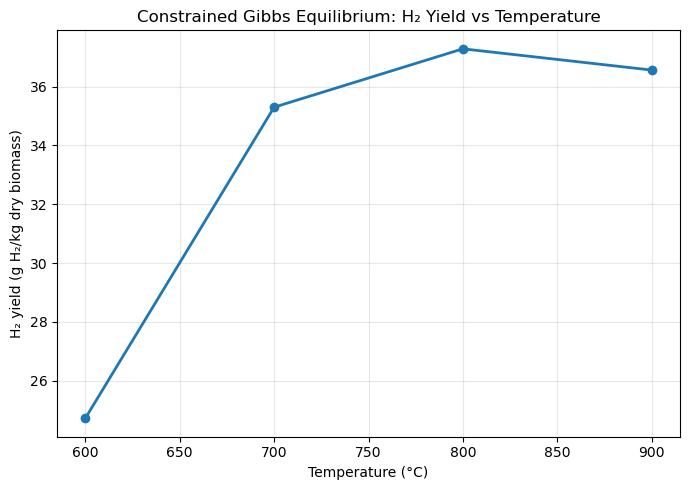


H₂ PRODUCTION TREND — CONSTRAINED MODEL
-----------------------------------------------------------------
600 °C : 37.98 mol% H₂ | 24.72 g/kg dry biomass
700 °C : 45.80 mol% H₂ | 35.30 g/kg dry biomass
800 °C : 46.78 mol% H₂ | 37.29 g/kg dry biomass
900 °C : 45.74 mol% H₂ | 36.57 g/kg dry biomass

Results saved to:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\constrained_model\constrained_gibbs_results.csv


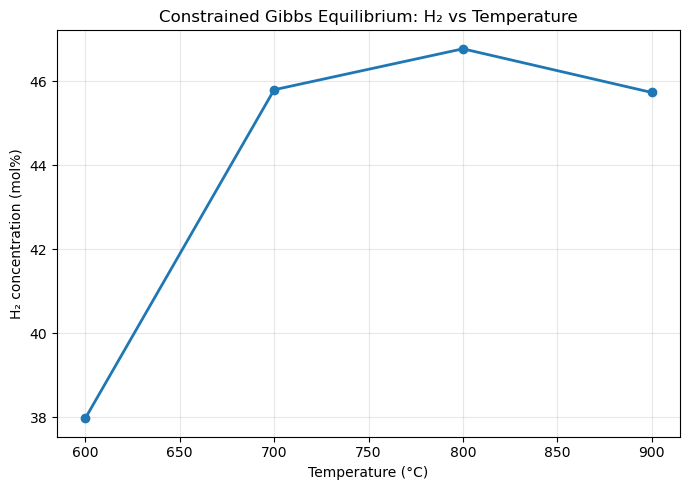

Saved:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\constrained_model\constrained_H2_mol_percent_vs_temperature.png


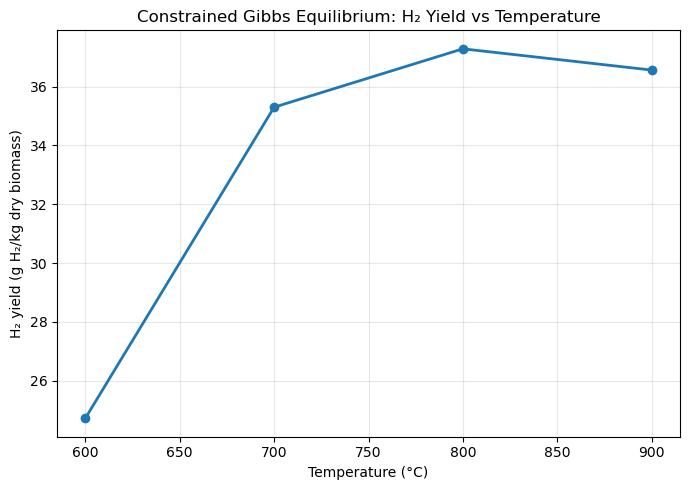

Saved:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\constrained_model\constrained_H2_yield_vs_temperature.png


In [4]:
# ============================================================
# CONSTRAINED GIBBS EQUILIBRIUM MODEL
# Pinewood pyrolysis: 600, 700, 800 and 900 °C
#
# Purpose:
# Compare constrained equilibrium H2 production across
# temperature while keeping the literature-informed
# bio-oil and char constraints fixed.
#
# IMPORTANT:
# This is a preliminary theoretical model.
# It is NOT a direct simulation of the batch reactor.
# ============================================================

import cantera as ct
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. FEEDSTOCK
# ============================================================

raw_pinewood_g = 300.0
moisture_fraction = 0.12

dry_mass_g = raw_pinewood_g * (1 - moisture_fraction)
moisture_mass_g = raw_pinewood_g * moisture_fraction
dry_mass_kg = dry_mass_g / 1000.0

print("FEED")
print("-" * 65)
print(f"Raw pinewood : {raw_pinewood_g:.2f} g")
print(f"Moisture     : {moisture_mass_g:.2f} g")
print(f"Dry biomass  : {dry_mass_g:.2f} g")
print(f"Dry biomass  : {dry_mass_kg:.4f} kg")


# ============================================================
# 2. YOUR PINEWOOD ULTIMATE ANALYSIS
# ============================================================

C_wt = 49.33
H_wt = 6.06
O_wt = 44.57
N_wt = 0.04

MW_C = 12.011
MW_H = 1.008
MW_O = 15.999
MW_N = 14.007
MW_H2 = 2.01588
MW_H2O = 18.01528

# Elemental masses
C_mass_g = dry_mass_g * C_wt / 100
H_mass_g = dry_mass_g * H_wt / 100
O_mass_g = dry_mass_g * O_wt / 100
N_mass_g = dry_mass_g * N_wt / 100

# Moles of atoms
C_moles = C_mass_g / MW_C
H_moles = H_mass_g / MW_H
O_moles = O_mass_g / MW_O
N_moles = N_mass_g / MW_N

# Moisture
water_moles = moisture_mass_g / MW_H2O

# Total feed elemental inventory including moisture
total_C = C_moles
total_H = H_moles + 2 * water_moles
total_O = O_moles + water_moles
total_N = N_moles

print("\nTOTAL FEED ELEMENTAL INVENTORY")
print("-" * 65)
print(f"C = {total_C:.6f} mol atoms")
print(f"H = {total_H:.6f} mol atoms")
print(f"O = {total_O:.6f} mol atoms")
print(f"N = {total_N:.6f} mol atoms")


# ============================================================
# 3. LITERATURE-INFORMED PRODUCT CONSTRAINTS
# ============================================================
#
# Bio-oil:
# 40.88 wt%
#
# Char:
# midpoint of reported 21.36-25.11 wt% range
#
# IMPORTANT:
# These are held CONSTANT for all temperatures in this model.
# Therefore this is a sensitivity study, not the final
# temperature-dependent product-distribution model.
# ============================================================

biooil_fraction = 0.4088
char_fraction = (21.36 + 25.11) / 2 / 100

gas_fraction = 1 - biooil_fraction - char_fraction

print("\nPRODUCT CONSTRAINTS")
print("-" * 65)
print(f"Bio-oil = {biooil_fraction * 100:.2f} wt%")
print(f"Char    = {char_fraction * 100:.2f} wt%")
print(f"Gas     = {gas_fraction * 100:.2f} wt%")


# ============================================================
# 4. BIO-OIL ELEMENTAL COMPOSITION
# ============================================================
#
# Literature composition:
# C = 71.55%
# H = 5.17%
# O = 21.34%
# N = 1.94%
#
# Because the feed used in our model contains only 0.04 wt% N,
# we exclude the literature N contribution and renormalize C/H/O.
# This is an explicit modelling assumption.
# ============================================================

biooil_C_raw = 71.55
biooil_H_raw = 5.17
biooil_O_raw = 21.34

biooil_CH0_sum = (
    biooil_C_raw +
    biooil_H_raw +
    biooil_O_raw
)

biooil_C_fraction = biooil_C_raw / biooil_CH0_sum
biooil_H_fraction = biooil_H_raw / biooil_CH0_sum
biooil_O_fraction = biooil_O_raw / biooil_CH0_sum

biooil_mass_g = dry_mass_g * biooil_fraction

biooil_C_moles = (
    biooil_mass_g * biooil_C_fraction / MW_C
)

biooil_H_moles = (
    biooil_mass_g * biooil_H_fraction / MW_H
)

biooil_O_moles = (
    biooil_mass_g * biooil_O_fraction / MW_O
)

print("\nBIO-OIL CONSTRAINT")
print("-" * 65)
print(f"Bio-oil mass = {biooil_mass_g:.4f} g")
print(f"C = {biooil_C_fraction * 100:.3f} wt%")
print(f"H = {biooil_H_fraction * 100:.3f} wt%")
print(f"O = {biooil_O_fraction * 100:.3f} wt%")
print("N = 0.000 wt% (model assumption)")


# ============================================================
# 5. CHAR ELEMENTAL COMPOSITION
# ============================================================
#
# Literature pine-biochar composition:
# C = 56.96%
# H = 2.89%
# O = 34.91%
# N = 0.26%
# Ash = 4.98%
#
# For the Cantera organic model:
# - ash is excluded
# - N is set to zero to remain consistent with the very low-N
#   feed used in our model
# - C/H/O are renormalized
#
# Again, this is a modelling assumption.
# ============================================================

char_C_raw = 56.96
char_H_raw = 2.89
char_O_raw = 34.91

char_CH0_sum = (
    char_C_raw +
    char_H_raw +
    char_O_raw
)

char_C_fraction = char_C_raw / char_CH0_sum
char_H_fraction = char_H_raw / char_CH0_sum
char_O_fraction = char_O_raw / char_CH0_sum

char_mass_g = dry_mass_g * char_fraction

char_C_moles = (
    char_mass_g * char_C_fraction / MW_C
)

char_H_moles = (
    char_mass_g * char_H_fraction / MW_H
)

char_O_moles = (
    char_mass_g * char_O_fraction / MW_O
)

print("\nCHAR CONSTRAINT")
print("-" * 65)
print(f"Char mass = {char_mass_g:.4f} g")
print(f"C = {char_C_fraction * 100:.3f} wt%")
print(f"H = {char_H_fraction * 100:.3f} wt%")
print(f"O = {char_O_fraction * 100:.3f} wt%")
print("N = 0.000 wt% (model assumption)")
print("Ash excluded from Cantera elemental model")


# ============================================================
# 6. ELEMENTS REMAINING FOR GAS
# ============================================================

gas_C_atoms = total_C - biooil_C_moles - char_C_moles
gas_H_atoms = total_H - biooil_H_moles - char_H_moles
gas_O_atoms = total_O - biooil_O_moles - char_O_moles
gas_N_atoms = total_N

print("\nGAS-PHASE ELEMENTAL INVENTORY")
print("-" * 65)
print(f"C = {gas_C_atoms:.6f} mol atoms")
print(f"H = {gas_H_atoms:.6f} mol atoms")
print(f"O = {gas_O_atoms:.6f} mol atoms")
print(f"N = {gas_N_atoms:.6f} mol atoms")


# ============================================================
# 7. CHECK CONSTRAINT FEASIBILITY
# ============================================================

for element, amount in {
    "C": gas_C_atoms,
    "H": gas_H_atoms,
    "O": gas_O_atoms,
    "N": gas_N_atoms
}.items():

    if amount < -1e-10:
        raise ValueError(
            f"Impossible constraint: negative {element} inventory "
            f"({amount:.8f} mol)."
        )


# ============================================================
# 8. CREATE INITIAL GAS COMPOSITION
# ============================================================
#
# We construct a gas composition containing exactly the remaining
# C/H/O/N inventory.
#
# Initial representation:
#   C -> CO
#   remaining O -> H2O
#   remaining H -> H2
#   N -> N2
#
# Gibbs equilibrium will redistribute these elements among the
# gas species available in gri30.yaml.
# ============================================================

CO_initial = gas_C_atoms

remaining_O = gas_O_atoms - CO_initial

if remaining_O < -1e-10:
    raise ValueError(
        "Not enough oxygen to construct the initial CO inventory."
    )

H2O_initial = min(
    remaining_O,
    gas_H_atoms / 2
)

remaining_H = gas_H_atoms - 2 * H2O_initial
remaining_O = remaining_O - H2O_initial

if abs(remaining_O) > 1e-8:
    raise ValueError(
        f"Initial gas construction leaves unassigned oxygen: "
        f"{remaining_O:.8f} mol."
    )

H2_initial = max(remaining_H / 2, 0.0)
N2_initial = gas_N_atoms / 2

initial_gas = {
    "CO": CO_initial,
    "H2O": H2O_initial,
    "H2": H2_initial,
    "N2": N2_initial
}

print("\nINITIAL GAS INVENTORY")
print("-" * 65)
for species, amount in initial_gas.items():
    print(f"{species:5s} = {amount:.6f} mol")


# ============================================================
# 9. PRE-EQUILIBRIUM GAS BALANCE CHECK
# ============================================================

C_check = CO_initial
H_check = 2 * H2_initial + 2 * H2O_initial
O_check = CO_initial + H2O_initial
N_check = 2 * N2_initial

print("\nPRE-EQUILIBRIUM GAS BALANCE CHECK")
print("-" * 65)
print(f"C difference = {C_check - gas_C_atoms:.10e} mol")
print(f"H difference = {H_check - gas_H_atoms:.10e} mol atoms")
print(f"O difference = {O_check - gas_O_atoms:.10e} mol")
print(f"N difference = {N_check - gas_N_atoms:.10e} mol")


# ============================================================
# 10. RUN EQUILIBRIUM FOR ALL TEMPERATURES
# ============================================================

temperatures_C = [600, 700, 800, 900]
pressure = ct.one_atm

results = []

for temperature_C in temperatures_C:

    temperature_K = temperature_C + 273.15

    # Fresh gas phase for each temperature
    gas = ct.Solution("gri30.yaml")

    # Solid carbon phase
    char = ct.Solution("graphite.yaml")

    # Set initial gas state
    gas.TPX = (
        temperature_K,
        pressure,
        initial_gas
    )

    # Set solid-char state
    char.TP = temperature_K, pressure

    # Amount of gas and solid phase initially
    gas_initial_moles = sum(initial_gas.values())
    char_initial_moles = char_C_moles

    # Create multiphase mixture
    mix = ct.Mixture([
        (gas, gas_initial_moles),
        (char, char_initial_moles)
    ])

    # Gibbs minimization at constant T and P
    mix.equilibrate("TP")

    # Get equilibrium phases
    gas_eq = mix.phase(0)

    gas_moles = mix.phase_moles(0)
    char_moles = mix.phase_moles(1)

    # Gas mole fractions
    H2_x = gas_eq["H2"].X[0]
    CO_x = gas_eq["CO"].X[0]
    CO2_x = gas_eq["CO2"].X[0]
    CH4_x = gas_eq["CH4"].X[0]
    H2O_x = gas_eq["H2O"].X[0]

    # H2 amount and yield
    H2_moles = H2_x * gas_moles
    H2_mass_g = H2_moles * MW_H2
    H2_yield_g_per_kg = H2_mass_g / dry_mass_kg
    H2_yield_mol_per_kg = H2_moles / dry_mass_kg

    results.append({
        "Temperature_C": temperature_C,
        "Gas_mol": gas_moles,
        "H2_mol": H2_moles,
        "H2_mol_percent": H2_x * 100,
        "CO_mol_percent": CO_x * 100,
        "CO2_mol_percent": CO2_x * 100,
        "CH4_mol_percent": CH4_x * 100,
        "H2O_mol_percent": H2O_x * 100,
        "Char_mol_C": char_moles,
        "H2_mass_g": H2_mass_g,
        "H2_yield_mol_per_kg": H2_yield_mol_per_kg,
        "H2_yield_g_per_kg": H2_yield_g_per_kg
    })


# ============================================================
# 11. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\nCONSTRAINED GIBBS EQUILIBRIUM RESULTS")
print("=" * 110)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "constrained_gibbs_temperature_results.csv",
    index=False
)

print("\nSaved:")
print("constrained_gibbs_temperature_results.csv")


# ============================================================
# 13. H2 CONCENTRATION PLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Temperature_C"],
    results_df["H2_mol_percent"],
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("H₂ concentration (mol%)")
plt.title("Constrained Gibbs Equilibrium: H₂ vs Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "constrained_H2_mol_percent_vs_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. H2 YIELD PLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Temperature_C"],
    results_df["H2_yield_g_per_kg"],
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("H₂ yield (g H₂/kg dry biomass)")
plt.title("Constrained Gibbs Equilibrium: H₂ Yield vs Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "constrained_H2_yield_vs_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. PRINT H2 TREND
# ============================================================

print("\nH₂ PRODUCTION TREND — CONSTRAINED MODEL")
print("-" * 65)

for _, row in results_df.iterrows():
    print(
        f"{int(row['Temperature_C'])} °C : "
        f"{row['H2_mol_percent']:.2f} mol% H₂ | "
        f"{row['H2_yield_g_per_kg']:.2f} g/kg dry biomass"
    )

import os

# ============================================================
# SAVE CONSTRAINED MODEL RESULTS
# ============================================================

output_folder = r"C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\constrained_model"

os.makedirs(output_folder, exist_ok=True)

# Save results table
csv_path = os.path.join(
    output_folder,
    "constrained_gibbs_results.csv"
)

results_df.to_csv(csv_path, index=False)

print(f"\nResults saved to:\n{csv_path}")


# ============================================================
# SAVE CONSTRAINED H2 MOL% GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Temperature_C"],
    results_df["H2_mol_percent"],
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("H₂ concentration (mol%)")
plt.title("Constrained Gibbs Equilibrium: H₂ vs Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path1 = os.path.join(
    output_folder,
    "constrained_H2_mol_percent_vs_temperature.png"
)

plt.savefig(path1, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved:\n{path1}")


# ============================================================
# SAVE CONSTRAINED H2 YIELD GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Temperature_C"],
    results_df["H2_yield_g_per_kg"],
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("H₂ yield (g H₂/kg dry biomass)")
plt.title("Constrained Gibbs Equilibrium: H₂ Yield vs Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path2 = os.path.join(
    output_folder,
    "constrained_H2_yield_vs_temperature.png"
)

plt.savefig(path2, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved:\n{path2}")

   Temperature_C  Unconstrained  Constrained
0            600          39.93        24.72
1            700          57.75        35.30
2            800          68.82        37.29
3            900          73.19        36.57

Saved to:
C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\constrained_model\unconstrained_vs_constrained_H2_yield.png


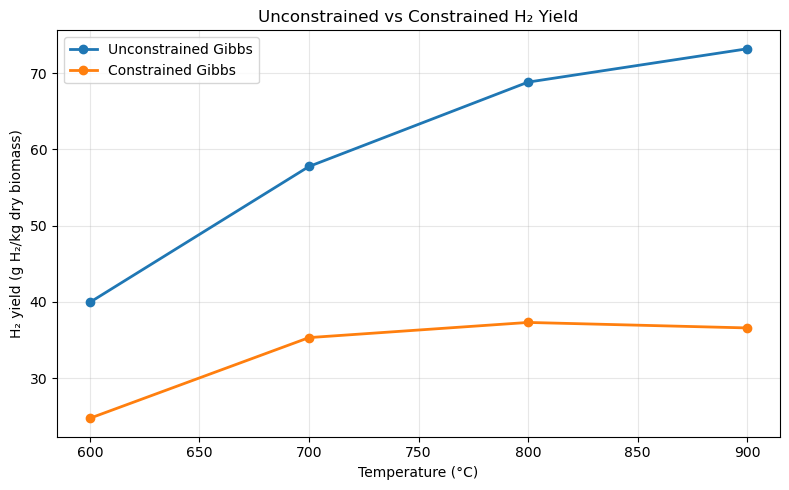

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# COMPARISON: H2 YIELD
# ============================================================

# Folder where the comparison graphs will be saved
output_folder = r"C:\Users\SANDRA\OneDrive\Desktop\PY_COMP\Cantera Study\constrained_model"

os.makedirs(output_folder, exist_ok=True)

# Temperature
temperature_C = [600, 700, 800, 900]

# Unconstrained Gibbs model
unconstrained_yield = [39.93, 57.75, 68.82, 73.19]

# Constrained Gibbs model
constrained_yield = [24.72, 35.30, 37.29, 36.57]

# Create dataframe
comparison_df = pd.DataFrame({
    "Temperature_C": temperature_C,
    "Unconstrained": unconstrained_yield,
    "Constrained": constrained_yield
})

print(comparison_df)

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    temperature_C,
    unconstrained_yield,
    marker="o",
    linewidth=2,
    label="Unconstrained Gibbs"
)

ax.plot(
    temperature_C,
    constrained_yield,
    marker="o",
    linewidth=2,
    label="Constrained Gibbs"
)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("H₂ yield (g H₂/kg dry biomass)")
ax.set_title("Unconstrained vs Constrained H₂ Yield")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

# SAVE BEFORE SHOW
save_path = os.path.join(
    output_folder,
    "unconstrained_vs_constrained_H2_yield.png"
)

fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"\nSaved to:\n{save_path}")

plt.show()
plt.close(fig)